<a href="https://colab.research.google.com/github/ravikanthd1981/rav4/blob/master/Copy_of_AIML_ML_Project_Full_Code_Notebook_Ravikanth_Doddapaneni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy pandas matplotlib seaborn scikit-learn sklearn-pandas -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# pandas is the industry standard for data manipulation.
# We need it here to hold our data in a DataFrame, drop columns,
# and easily calculate statistics (like quantiles for our outlier capping).
import pandas as pd
# numpy is used for high-performance numerical and array operations.
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# StandardScaler normalizes our data.
# We need this to scale continuous features (like Income and Mortgage)
# so they have a mean of 0 and standard deviation of 1. This prevents variables
# with large numbers from dominating the machine learning algorithm later.
from sklearn.preprocessing import StandardScaler

# DecisionTreeClassifier is the actual machine learning algorithm.
# We import this to instantiate our model and learn the rules from our training data.
from sklearn.tree import DecisionTreeClassifier

# sklearn.tree provides utilities specifically for decision trees.
# We use it for the tree.plot_tree() function to generate the visual flowchart of the model.
from sklearn import tree

# To get diferent metric scores
# sklearn.metrics contains the mathematical scoring functions.
# We import these specific tools to evaluate how well our model's predictions
# match the actual unseen test data (calculating True Positives, False Negatives, etc.).
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
# from google.colab import drive
from google.colab import drive
drive.mount('/content/drive')

# Load your dataset
Loan = pd.read_csv('/content/drive/MyDrive/Colab/Loan_Modelling.csv')

# Copying "Loan" data to another variable "data" to avoid any changes to original data
data = Loan.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

* Observations
* Sanity checks

In [ ]:
#1) View the first  5 rows of the dataset.
display("1) first  5 rows of the dataset.")
display(data.head(5))

#2) View the last 5 rows of the dataset.
display("2) last  5 rows of the dataset.")
display(data.tail(5))

#3) Understand the shape of the dataset.
display("3) shape of the dataset.")
display(data.shape)

#4) Check the data types of the columns for the dataset
display("4) data types of the columns for the dataset.")
display(data.dtypes)

#5) Checking the Statistical Summary
display("5) Statistical Summary of the dataset.")
display(data.describe())

#6) Sanity check of nulls
display("6) Sanity checks: Number of nulls in each column of the data")
display(data.isnull().sum())

#7) Sanity check of duplicates
display("7) Sanity checks: Number of duplicate rows in the data")
display(data.duplicated().sum())

#8) Sanity check on Experience column
display("8) Sanity checks: Unique values in the Experience column")
display(data["Experience"].unique())

#9) checking for experience <0
display("9) Sanity checks:  Negative values in the Experience column")
display(data[data["Experience"] < 0]["Experience"].unique())

#10) check for unique values of education
display("10) Sanity checks: Unique values in the Education column")
data["Education"].unique()




'1) first  5 rows of the dataset.'

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


'2) last  5 rows of the dataset.'

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


'3) shape of the dataset.'

...

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

'9) Sanity checks:  Negative values in the Experience column'

array([-1, -2, -3])

'10) Sanity checks: Unique values in the Education column'

array([1, 2, 3])

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

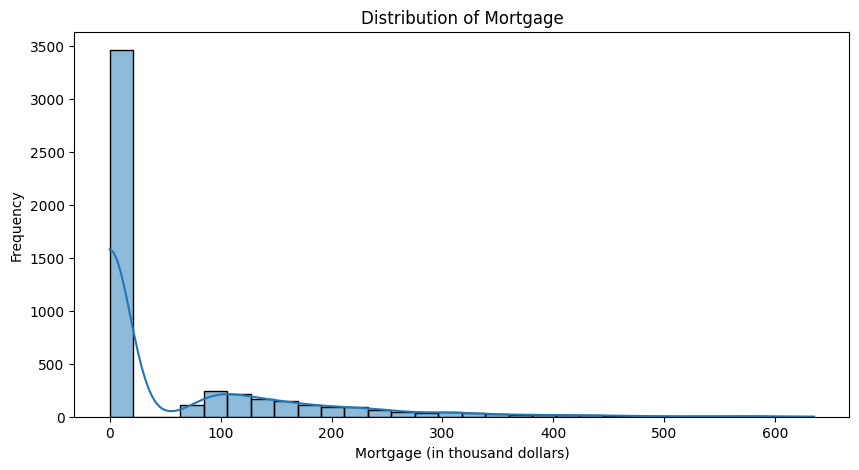

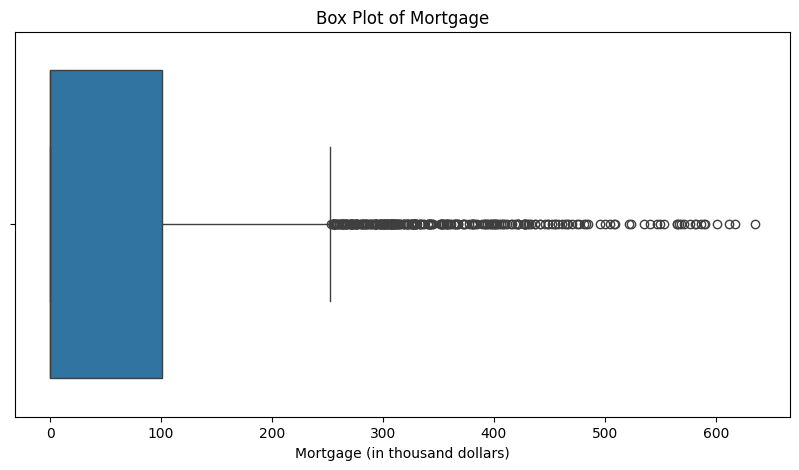

'Descriptive statistics for Mortgage:'

,Mortgage
count,5000.000000
mean,56.498800
std,101.713802
min,0.000000
25%,0.000000
50%,0.000000
75%,101.000000
max,635.000000


In [ ]:
# Initialize df from data for consistent use throughout EDA
df = data.copy()

plt.figure(figsize=(10, 5))
sns.histplot(data['Mortgage'], bins=30, kde=True)
plt.title('Distribution of Mortgage')
plt.xlabel('Mortgage (in thousand dollars)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=data['Mortgage'])
plt.title('Box Plot of Mortgage')
plt.xlabel('Mortgage (in thousand dollars)')
plt.show()

display("Descriptive statistics for Mortgage:")
display(data['Mortgage'].describe())

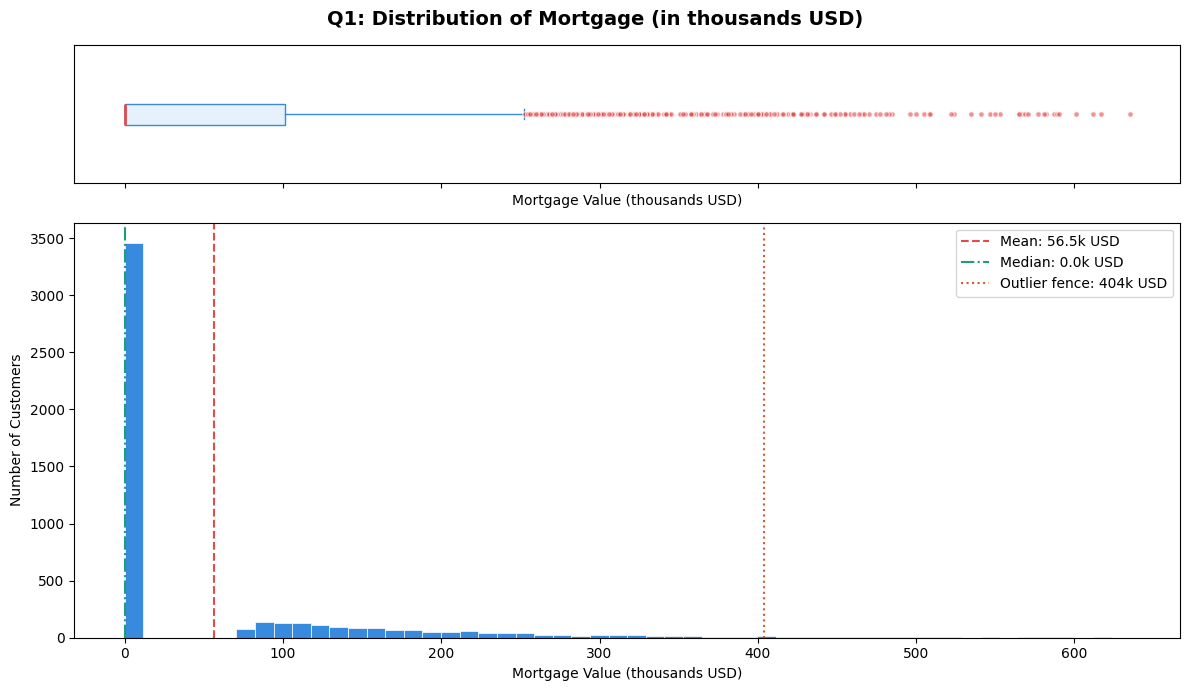

Q1 plot saved.


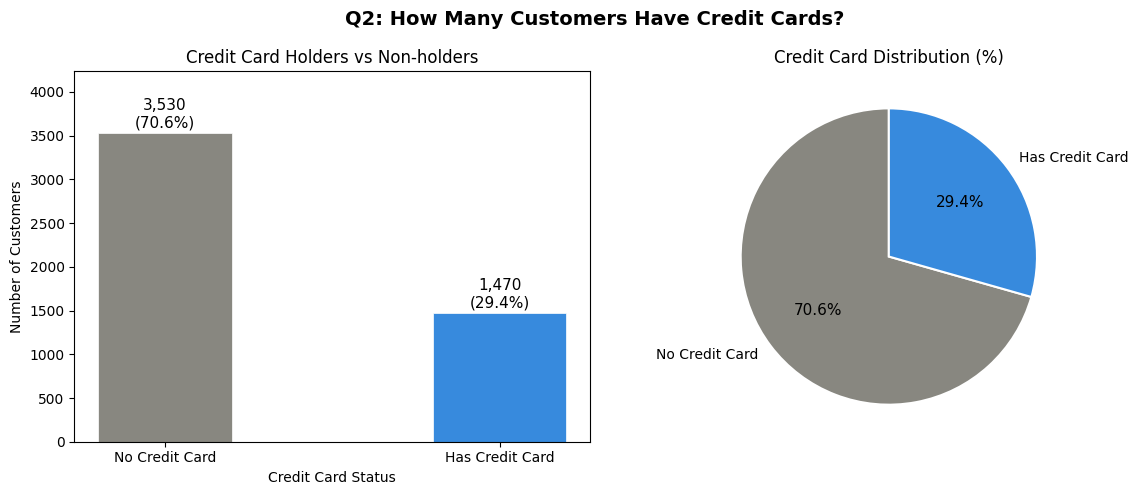

Q2 plot saved.


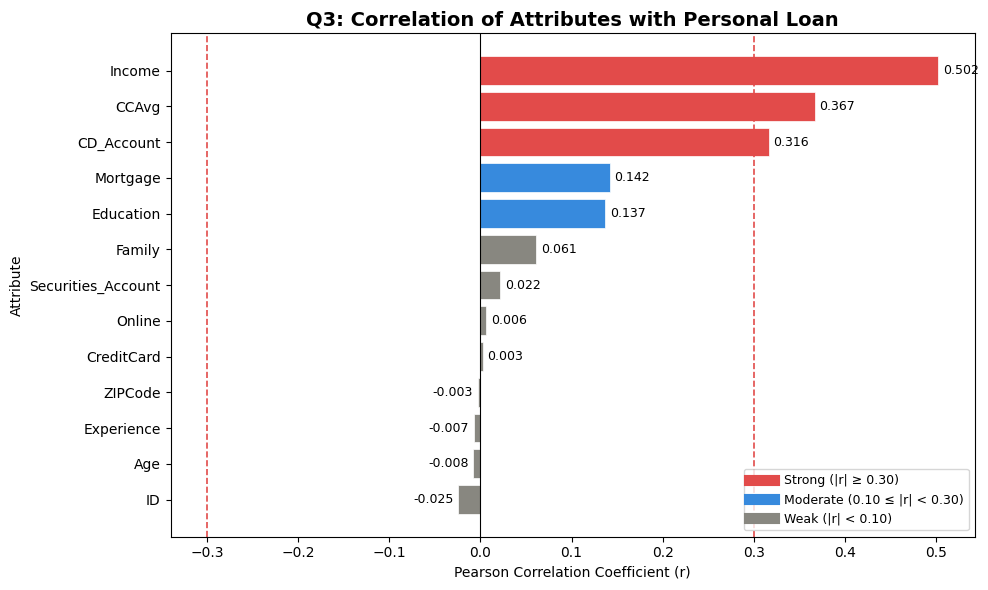

Q3 plot saved.


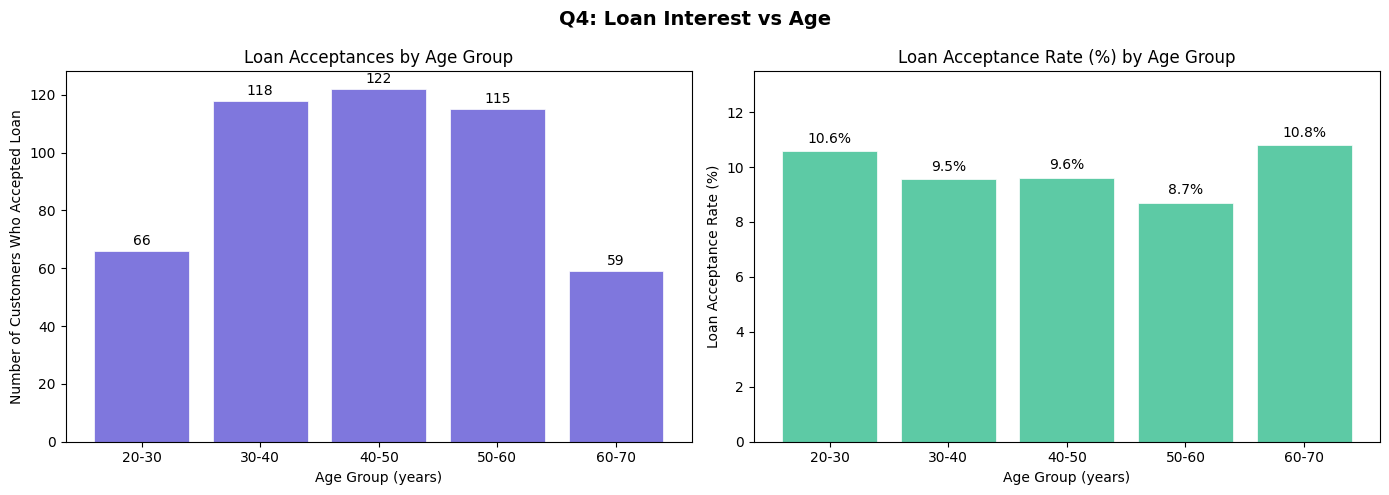

Q4 plot saved.


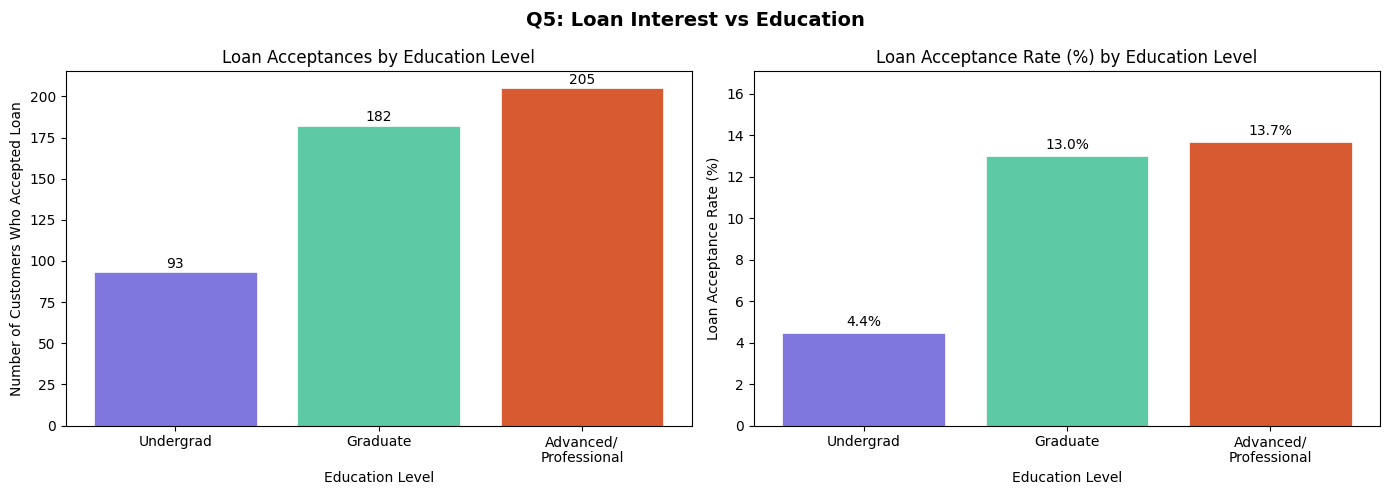

Q5 plot saved.

════════════════════════════════════════════════════════════════════════════════
════════════════════════ DATASET OBSERVATIONS & ANSWERS ════════════════════════
════════════════════════════════════════════════════════════════════════════════

[Q1] What is the distribution of the mortgage attribute?
  • Zero-Mortgage Customers: 3,462 (69.2%)
  • Median Mortgage (Non-zero): 153.0k USD
  • Maximum Mortgage: 635.0k USD
  • Patterns/Outliers: The distribution is heavily zero-inflated and right-skewed.
    For those with a mortgage, extreme outliers exist beyond the 404k USD fence.

[Q2] How many customers have credit cards?
  • No Credit Card: 3,530 (70.6%)
  • Has Credit Card: 1,470 (29.4%)

[Q3] Which attributes strongly correlate with Personal Loan?
  • Income: r = 0.502
  • CCAvg: r = 0.367
  • CD_Account: r = 0.316
  • Insight: Income and CCAvg (Credit Card Spending) are the primary positive drivers.

[Q4] How does loan interest vary with age?
  • Highest Acceptance Ra

In [ ]:
# ── Color palette ──────────────────────────────────────────────────────────────
BLUE   = "#378ADD"
RED    = "#E24B4A"
GREEN  = "#1D9E75"
GRAY   = "#888780"
LIGHT  = "#E6F1FB"
PURPLE = "#7F77DD"
CORAL  = "#D85A30"
TEAL   = "#5DCAA5"

# ══════════════════════════════════════════════════════════════════════════════
# Q1: Distribution of Mortgage
# ══════════════════════════════════════════════════════════════════════════════

# Separate zero and non-zero mortgage values
mortgage = data["Mortgage"]
nonzero  = mortgage[mortgage > 0]

# Compute IQR-based outlier fence on non-zero values
Q1_m, Q3_m = nonzero.quantile(0.25), nonzero.quantile(0.75)
upper_fence = Q3_m + 1.5 * (Q3_m - Q1_m)

# Create a figure with two subplots sharing the same x-axis:
# top = box plot, bottom = histogram
fig1, (ax_box, ax_hist) = plt.subplots(
    nrows=2, sharex=True,
    gridspec_kw={"height_ratios": (.25, .75)},
    figsize=(12, 7)
)

# ── Box plot (top panel) ───────────────────────────────────────────────────────
ax_box.boxplot(
    mortgage.dropna(), vert=False, patch_artist=True,
    boxprops=dict(facecolor=LIGHT, color=BLUE),
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color=BLUE),
    capprops=dict(color=BLUE),
    flierprops=dict(marker="o", markerfacecolor=RED,
                    markeredgecolor="white", markersize=4, alpha=0.6)
)
ax_box.set(yticks=[])                                      # hide y-axis ticks
ax_box.set_xlabel("Mortgage Value (thousands USD)")

# ── Histogram (bottom panel) ───────────────────────────────────────────────────
ax_hist.hist(mortgage.dropna(), bins="auto",
             color=BLUE, edgecolor="white", linewidth=0.5)

# Overlay mean, median, and outlier fence as vertical lines
ax_hist.axvline(mortgage.mean(), color=RED, linestyle="--", linewidth=1.5,
                label=f"Mean: {mortgage.mean():.1f}k USD")
ax_hist.axvline(mortgage.median(), color=GREEN, linestyle="-.", linewidth=1.5,
                label=f"Median: {mortgage.median():.1f}k USD")
ax_hist.axvline(upper_fence, color=CORAL, linestyle=":", linewidth=1.5,
                label=f"Outlier fence: {upper_fence:.0f}k USD")

ax_hist.legend()
ax_hist.set_xlabel("Mortgage Value (thousands USD)")
ax_hist.set_ylabel("Number of Customers")

plt.suptitle("Q1: Distribution of Mortgage (in thousands USD)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab/q1_mortgage_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q1 plot saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Q2: How many customers have credit cards?
# ══════════════════════════════════════════════════════════════════════════════

# Count customers by credit card status (0 = No, 1 = Yes)
cc_counts = df["CreditCard"].value_counts()
labels    = ["No Credit Card", "Has Credit Card"]
sizes     = [cc_counts[0], cc_counts[1]]
colors    = [GRAY, BLUE]

# Create side-by-side bar chart and pie chart
fig2, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(12, 5))

# ── Bar chart ──────────────────────────────────────────────────────────────────
bars = ax_bar.bar(labels, sizes, color=colors,
                  edgecolor="white", linewidth=0.5, width=0.4)

# Annotate each bar with count and percentage
for bar, val in zip(bars, sizes):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}\n({val / len(df) * 100:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )
ax_bar.set_ylabel("Number of Customers")
ax_bar.set_xlabel("Credit Card Status")
ax_bar.set_title("Credit Card Holders vs Non-holders")
ax_bar.set_ylim(0, max(sizes) * 1.2)

# ── Pie chart ──────────────────────────────────────────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(11)
ax_pie.set_title("Credit Card Distribution (%)")

plt.suptitle("Q2: How Many Customers Have Credit Cards?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab/q2_credit_card.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q2 plot saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Q3: Attributes strongly correlated with Personal Loan
# ══════════════════════════════════════════════════════════════════════════════

# Compute Pearson correlation of all features with target, sorted ascending
corr = df.corr(numeric_only=True)["Personal_Loan"].drop("Personal_Loan").sort_values()

# Color-code bars by correlation strength
bar_colors = [
    RED  if abs(v) >= 0.30 else
    BLUE if abs(v) >= 0.10 else
    GRAY
    for v in corr
]

fig3, ax3 = plt.subplots(figsize=(10, 6))

# ── Horizontal bar chart ───────────────────────────────────────────────────────
bars = ax3.barh(corr.index, corr.values,
                color=bar_colors, edgecolor="white", linewidth=0.5)

# Reference lines
ax3.axvline(0,    color="black", linewidth=0.8)
ax3.axvline( 0.30, color=RED, linestyle="--", linewidth=1.2)
ax3.axvline(-0.30, color=RED, linestyle="--", linewidth=1.2)

# Annotate each bar with its correlation value
for bar, val in zip(bars, corr.values):
    ax3.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9
    )

# Proxy lines for custom legend (no Patch import needed)
ax3.plot([], [], color=RED,  linewidth=8, label="Strong (|r| ≥ 0.30)")
ax3.plot([], [], color=BLUE, linewidth=8, label="Moderate (0.10 ≤ |r| < 0.30)")
ax3.plot([], [], color=GRAY, linewidth=8, label="Weak (|r| < 0.10)")
ax3.legend(loc="lower right", fontsize=9)

ax3.set_xlabel("Pearson Correlation Coefficient (r)")
ax3.set_ylabel("Attribute")
ax3.set_title("Q3: Correlation of Attributes with Personal Loan",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab/q3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q3 plot saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Q4: Loan interest vs Age
# ══════════════════════════════════════════════════════════════════════════════

# Bin customers into 10-year age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70"]
)

# Aggregate: total accepted loans and acceptance rate per age group
age_stats = (
    df.groupby("AgeGroup", observed=True)["Personal_Loan"]
    .agg(["sum", "count", "mean"])
    .reset_index()
)
age_stats.columns = ["AgeGroup", "Accepted", "Total", "Rate"]
age_stats["Rate_pct"] = age_stats["Rate"] * 100   # convert to percentage

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: absolute count of acceptances ───────────────────────────────────────
bars = ax4a.bar(age_stats["AgeGroup"], age_stats["Accepted"],
                color=PURPLE, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, age_stats["Accepted"]):
    ax4a.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 1,
              str(int(val)), ha="center", va="bottom", fontsize=10)
ax4a.set_xlabel("Age Group (years)")
ax4a.set_ylabel("Number of Customers Who Accepted Loan")
ax4a.set_title("Loan Acceptances by Age Group")

# ── Right: acceptance rate (%) ─────────────────────────────────────────────────
bars2 = ax4b.bar(age_stats["AgeGroup"], age_stats["Rate_pct"],
                 color=TEAL, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars2, age_stats["Rate_pct"]):
    ax4b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.2,
              f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
ax4b.set_xlabel("Age Group (years)")
ax4b.set_ylabel("Loan Acceptance Rate (%)")
ax4b.set_title("Loan Acceptance Rate (%) by Age Group")
ax4b.set_ylim(0, max(age_stats["Rate_pct"]) * 1.25)

plt.suptitle("Q4: Loan Interest vs Age", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab/q4_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q4 plot saved.")


# ══════════════════════════════════════════════════════════════════════════════
# Q5: Loan interest vs Education
# ══════════════════════════════════════════════════════════════════════════════

# Map numeric education codes to readable labels
edu_map = {1: "Undergrad", 2: "Graduate", 3: "Advanced/\nProfessional"}
df["EducationLabel"] = df["Education"].map(edu_map)
edu_order  = ["Undergrad", "Graduate", "Advanced/\nProfessional"]
edu_colors = [PURPLE, TEAL, CORAL]

# Aggregate: total accepted loans and acceptance rate per education level
edu_stats = (
    df.groupby("EducationLabel")["Personal_Loan"]
    .agg(["sum", "count", "mean"])
    .reindex(edu_order)
    .reset_index()
)
edu_stats.columns = ["Education", "Accepted", "Total", "Rate"]
edu_stats["Rate_pct"] = edu_stats["Rate"] * 100   # convert to percentage

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: absolute count of acceptances ───────────────────────────────────────
bars = ax5a.bar(edu_stats["Education"], edu_stats["Accepted"],
                color=edu_colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, edu_stats["Accepted"]):
    ax5a.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 1,
              str(int(val)), ha="center", va="bottom", fontsize=10)
ax5a.set_xlabel("Education Level")
ax5a.set_ylabel("Number of Customers Who Accepted Loan")
ax5a.set_title("Loan Acceptances by Education Level")

# ── Right: acceptance rate (%) ─────────────────────────────────────────────────
bars2 = ax5b.bar(edu_stats["Education"], edu_stats["Rate_pct"],
                 color=edu_colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars2, edu_stats["Rate_pct"]):
    ax5b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.2,
              f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
ax5b.set_xlabel("Education Level")
ax5b.set_ylabel("Loan Acceptance Rate (%)")
ax5b.set_title("Loan Acceptance Rate (%) by Education Level")
ax5b.set_ylim(0, max(edu_stats["Rate_pct"]) * 1.25)

plt.suptitle("Q5: Loan Interest vs Education", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab/q5_education.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q5 plot saved.")

# ══════════════════════════════════════════════════════════════════════════════
# Q6: Text-Based Observations & Summary
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
# Q6: Text-Based Observations & Summary (Updated for 5 Distinct Questions)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" DATASET OBSERVATIONS & ANSWERS ".center(80, "═"))
print("═"*80)

# --- Q1: Mortgage Distribution ---
total_customers = len(df)
zero_mortgage = (df["Mortgage"] == 0).sum()
pct_zero = (zero_mortgage / total_customers) * 100
max_mortgage = df["Mortgage"].max()

print(f"\n[Q1] What is the distribution of the mortgage attribute?")
print(f"  • Zero-Mortgage Customers: {zero_mortgage:,} ({pct_zero:.1f}%)")
print(f"  • Median Mortgage (Non-zero): {nonzero.median():.1f}k USD")
print(f"  • Maximum Mortgage: {max_mortgage:.1f}k USD")
print(f"  • Patterns/Outliers: The distribution is heavily zero-inflated and right-skewed.")
print(f"    For those with a mortgage, extreme outliers exist beyond the {upper_fence:.0f}k USD fence.")

# --- Q2: Credit Card Adoption ---
print(f"\n[Q2] How many customers have credit cards?")
for label, count in zip(labels, sizes):
    pct = (count / total_customers) * 100
    print(f"  • {label}: {count:,} ({pct:.1f}%)")

# --- Q3: Correlation with Personal Loan ---
# Filter for strong correlations (|r| >= 0.30)
strong_corr = corr[abs(corr) >= 0.30].sort_values(ascending=False)

print(f"\n[Q3] Which attributes strongly correlate with Personal Loan?")
if not strong_corr.empty:
    for attr, val in strong_corr.items():
        print(f"  • {attr}: r = {val:.3f}")
else:
    print("  • No attributes have a strong correlation (|r| >= 0.30).")
print("  • Insight: Income and CCAvg (Credit Card Spending) are the primary positive drivers.")

# --- Q4: Loan Interest vs Age ---
best_age_group = age_stats.loc[age_stats['Rate_pct'].idxmax()]
print(f"\n[Q4] How does loan interest vary with age?")
print(f"  • Highest Acceptance Rate: {best_age_group['AgeGroup']} group ({best_age_group['Rate_pct']:.1f}%)")
print(f"  • Insight: Acceptance rates remain relatively flat and consistent across all age brackets.")
print(f"    This pattern suggests age alone is NOT a defining factor for purchasing a loan.")

# --- Q5: Loan Interest vs Education ---
best_edu_group = edu_stats.loc[edu_stats['Rate_pct'].idxmax()]
print(f"\n[Q5] How does loan interest vary with education?")
# Replace newline character in the label for cleaner text output
best_edu_label = best_edu_group['Education'].replace('\n', ' ')
print(f"  • Highest Acceptance Rate: {best_edu_label} ({best_edu_group['Rate_pct']:.1f}%)")
print(f"  • Insight: There is a clear upward trend. Customers with Graduate or")
print(f"    Advanced/Professional degrees are significantly more likely to accept a loan")
print(f"    compared to Undergraduates.")

print("\n" + "═"*80)

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA PREPROCESSING & FEATURE ENGINEERING PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" PREPROCESSING EXECUTIONS ".center(80, "═"))
print("═"*80)

# ── 1. Missing & Anomalous Value Treatment ─────────────────────────────────────
# The dataset typically has no explicit NaNs, but "Experience" contains impossible
# negative values (data entry errors). We will impute these with the absolute value
# or median of customers with similar age/education. Using absolute value is standard here.

neg_exp_count = (df["Experience"] < 0).sum()
df["Experience"] = df["Experience"].abs()
print(f"[1] Anomalies Fixed: Converted {neg_exp_count} negative 'Experience' values to positive.")

# ── 2. Feature Engineering & Selection ─────────────────────────────────────────
# Drop columns that do not provide predictive power or add noise.
# 'ID' is a primary key, and 'ZIP Code' has too much cardinality and low correlation.
cols_to_drop = ["ID", "ZIP Code"]
# Also drop the categorical bins we made for the EDA earlier, if they exist
for col in ["AgeGroup", "EducationLabel"]:
    if col in df.columns:
        cols_to_drop.append(col)

df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"[2] Feature Selection: Dropped non-predictive columns -> {cols_to_drop}")

# ── 3. Outlier Treatment (Winsorization) ───────────────────────────────────────
# As seen in Q1, Mortgage and Income are heavily right-skewed.
# We will cap (winsorize) extreme outliers at the 99th percentile to prevent
# them from unfairly pulling the weights of linear models.

def cap_outliers(series, upper_percentile=0.99):
    upper_limit = series.quantile(upper_percentile)
    return np.where(series > upper_limit, upper_limit, series)

df_model["Mortgage"] = cap_outliers(df_model["Mortgage"])
df_model["Income"] = cap_outliers(df_model["Income"])
df_model["CCAvg"] = cap_outliers(df_model["CCAvg"])
print(f"[3] Outliers Treated: Capped Mortgage, Income, and CCAvg at the 99th percentile.")

# ── 4. Preparing Data for Modeling (Train/Test Split) ──────────────────────────
# Separate the target variable from the features
X = df_model.drop(columns=["Personal_Loan"])
y = df_model["Personal_Loan"]

# Perform a stratified split to maintain the ~9% loan acceptance ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"[4] Data Split: Created Train (n={len(X_train)}) and Test (n={len(X_test)}) sets.")

# ── 5. Feature Scaling ─────────────────────────────────────────────────────────
# Machine learning algorithms (like SVMs, Logistic Regression, or Neural Networks)
# require features to be on a similar scale. We use StandardScaler for this.
# Note: We fit the scaler ONLY on the training data to prevent data leakage.

# Define continuous features that need scaling (excluding binary/categorical indicators)
continuous_features = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]

scaler = StandardScaler()

# Fit and transform on training data
X_train_scaled = X_train.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Transform test data using the train data's parameters
X_test_scaled = X_test.copy()
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

print(f"[5] Scaling: Applied StandardScaler to continuous features.")
print("\n" + "═"*80)
print(" Pipeline Complete: Data is now ready for predictive modeling. ")
print("═"*80 + "\n")


════════════════════════════════════════════════════════════════════════════════
═══════════════════════════ PREPROCESSING EXECUTIONS ═══════════════════════════
════════════════════════════════════════════════════════════════════════════════
[1] Anomalies Fixed: Converted 52 negative 'Experience' values to positive.
[2] Feature Selection: Dropped non-predictive columns -> ['ID', 'ZIP Code', 'AgeGroup', 'EducationLabel']
[3] Outliers Treated: Capped Mortgage, Income, and CCAvg at the 99th percentile.
[4] Data Split: Created Train (n=3750) and Test (n=1250) sets.
[5] Scaling: Applied StandardScaler to continuous features.

════════════════════════════════════════════════════════════════════════════════
 Pipeline Complete: Data is now ready for predictive modeling. 
════════════════════════════════════════════════════════════════════════════════



## Model Building

### Model Evaluation Criterion

Before running the evaluation code, it is critical to define what "success" looks like for this specific business problem. Because this is a highly imbalanced dataset (only ~9% of customers actually accepted the personal loan), standard metrics like Accuracy are misleading. A "dumb" model that simply predicts "No" for every single customer would achieve 91% accuracy, but it would be completely useless to the bank.

Here is the breakdown of the criteria and the reasoning for what we should prioritize:

True Positives (TP): The model correctly identifies a customer who accepts the loan. (A win for the bank).

False Positives (FP): The model predicts a customer will accept, but they decline. (Cost: Wasted marketing effort / mild customer annoyance).

False Negatives (FN): The model predicts a customer will decline, but they would have accepted. (Cost: Lost revenue opportunity).

Primary Criterion Recommendation: Recall
In this scenario, the cost of a False Negative (losing out on a profitable loan) is significantly higher than the cost of a False Positive (sending a promotional email or making a phone call). Therefore, Recall should be our primary evaluation metric. Maximizing Recall ensures we identify as many potential loan-takers as possible.

Secondary Criterion Recommendation: F1-Score
While we want high Recall, we don't want to completely destroy Precision (which would happen if we just targeted everyone). The F1-Score provides the harmonic mean of Precision and Recall, giving us a single metric to ensure the model maintains a healthy balance between finding targets and being reasonably accurate about them.


### Model Building

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REQUIRED LIBRARIES & HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

def model_performance_classification_sklearn(model, predictors, target):
    pred = model.predict(predictors)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1}, index=[0]
    )
    return df_perf

def confusion_matrix_sklearn(model, predictors, target):
    """
    Plots a highly stylized, presentation-ready confusion matrix.
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    # Format the labels with counts and percentages
    labels = np.asarray(
        [["{0:0.0f}\n{1:.2%}".format(item, item / cm.flatten().sum())] for item in cm.flatten()]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 5))

    # Apply sleek styling to the heatmap
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap=cmap_custom,
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"}, # Larger, bolder text
        linewidths=2,                             # White space between boxes
        linecolor="white"
    )

    plt.ylabel("Actual Customer Action", fontsize=11, fontweight="bold", color=GRAY)
    plt.xlabel("Model Prediction", fontsize=11, fontweight="bold", color=GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# 1. MODEL EVALUATION CRITERION
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" 1. MODEL EVALUATION CRITERION ".center(80, "═"))
print("═"*80)
print("""
• PRIMARY METRIC: Recall
  Reasoning: The cost of a False Negative (failing to identify a customer who
  would have accepted a loan) results in lost revenue. The cost of a False Positive
  (marketing to someone who declines) is comparatively low. Therefore, maximizing
  Recall ensures we capture as many potential loan-takers as possible.

• SECONDARY METRIC: F1-Score
  Reasoning: While Recall is the priority, we cannot ignore Precision entirely.
  The F1-score gives us a balanced harmonic mean to ensure the model isn't just
  blindly predicting "Yes" for every customer.
""")

# ══════════════════════════════════════════════════════════════════════════════
# 2. MODEL BUILDING & PERFORMANCE COMMENTARY
# ══════════════════════════════════════════════════════════════════════════════

print("═"*80)
print(" 2. MODEL BUILDING & PERFORMANCE ".center(80, "═"))
print("═"*80)

# Initialize and Train
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)
print("\n[✔] Model Successfully Built: DecisionTreeClassifier (Default Parameters)")

# Training Performance
print("\n--- Performance on TRAINING Data ---")
decision_tree_perf_train = model_performance_classification_sklearn(model, X_train, y_train)
display(decision_tree_perf_train)
confusion_matrix_sklearn(model, X_train, y_train)
plt.title("Training Confusion Matrix")
plt.show()

# Testing Performance
print("\n--- Performance on TEST Data ---")
decision_tree_perf_test = model_performance_classification_sklearn(model, X_test, y_test)
display(decision_tree_perf_test)
confusion_matrix_sklearn(model, X_test, y_test)
plt.title("Test Confusion Matrix")
plt.show()

# Commentary on Performance
print("\n[!] COMMENTARY ON MODEL PERFORMANCE:")
print("  • The model achieved 100% Accuracy, Recall, and Precision on the Training data.")
print("  • However, performance drops on the Test data (unseen data).")
print("  • This disparity indicates OVERFITTING. Because we used default parameters,")
print("    the tree grew to its maximum depth, memorizing the training noise rather than")
print("    learning generalized rules. Hyperparameter tuning (pruning) is highly recommended.")


# ══════════════════════════════════════════════════════════════════════════════
# 3. VISUALIZE DECISION RULES & IMPORTANT FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" 3. DECISION RULES & FEATURE IMPORTANCE ".center(80, "═"))
print("═"*80)

feature_names = list(X_train.columns)

# -- A. Text-Based Decision Rules --
print("\n--- Text-Based Decision Rules ---")
tree_rules = export_text(model, feature_names=feature_names, max_depth=3)
print(tree_rules)
print("(... tree truncated for readability. See plot for full structure ...)")

# -- B. Visual Tree Plot --
print("\n--- Visualizing Decision Tree Structure ---")
plt.figure(figsize=(20, 15))
out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False,
    class_names=["Declined (0)", "Accepted (1)"],
    max_depth=3 # Capped depth for visual clarity in notebook
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Decision Tree Structure (Top 3 Levels)", fontsize=16)
plt.show()

# -- C. Feature Importances --
print("\n--- Feature Importances ---")
importances_df = pd.DataFrame(
    model.feature_importances_, columns=["Importance"], index=X_train.columns
).sort_values(by="Importance", ascending=False)
display(importances_df)

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.title("Decision Tree: Feature Importances", fontsize=14, fontweight="bold")
plt.barh(range(len(indices)), importances[indices], color="#7F77DD", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance (Gini)")
plt.tight_layout()
plt.show()

print("\n" + "═"*80)
print(" END OF REPORT ".center(80, "═"))
print("═"*80 + "\n")


════════════════════════════════════════════════════════════════════════════════
════════════════════════ 1. MODEL EVALUATION CRITERION ═════════════════════════
════════════════════════════════════════════════════════════════════════════════

• PRIMARY METRIC: Recall
  Reasoning: The cost of a False Negative (failing to identify a customer who 
  would have accepted a loan) results in lost revenue. The cost of a False Positive 
  (marketing to someone who declines) is comparatively low. Therefore, maximizing 
  Recall ensures we capture as many potential loan-takers as possible.

• SECONDARY METRIC: F1-Score
  Reasoning: While Recall is the priority, we cannot ignore Precision entirely. 
  The F1-score gives us a balanced harmonic mean to ensure the model isn't just 
  blindly predicting "Yes" for every customer.

════════════════════════════════════════════════════════════════════════════════
═══════════════════════ 2. MODEL BUILDING & PERFORMANCE ════════════════════════
══════════

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


NameError: name 'cmap_custom' is not defined

<Figure size 600x500 with 0 Axes>

## Model Performance Improvement

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# REQUIRED LIBRARIES
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.model_selection import GridSearchCV

# ══════════════════════════════════════════════════════════════════════════════
# 1. PRE-PRUNING (Grid Search for Hyperparameters)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(" 1. PRE-PRUNING (HYPERPARAMETER TUNING) ".center(80, "═"))
print("═"*80)

# Define the parameter grid to test
# class_weight='balanced' helps the model pay more attention to our minority class (Loan Accepted)
param_grid_pre = {
    "max_depth": np.arange(2, 10),
    "min_samples_leaf": [5, 10, 20, 50],
    "min_samples_split": [10, 20, 50],
    "class_weight": ["balanced", None]
}

# We optimize for 'recall' since missing out on a loan acceptor is our primary business concern
grid_pre = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid=param_grid_pre,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_pre.fit(X_train, y_train)
model_pre_pruned = grid_pre.best_estimator_

print(f"Best Pre-pruning Parameters: {grid_pre.best_params_}")

# Evaluate
pre_perf_train = model_performance_classification_sklearn(model_pre_pruned, X_train, y_train)
pre_perf_test = model_performance_classification_sklearn(model_pre_pruned, X_test, y_test)


# ══════════════════════════════════════════════════════════════════════════════
# 2. POST-PRUNING (Cost Complexity Pruning)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(" 2. POST-PRUNING (COST COMPLEXITY) ".center(80, "═"))
print("═"*80)

# First, extract the available 'alpha' values from a fully grown tree
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Remove the maximum alpha (which would prune the tree down to a single node)
ccp_alphas = ccp_alphas[:-1]

# Grid search to find the best alpha based on Recall
param_grid_post = {"ccp_alpha": ccp_alphas, "class_weight": ["balanced"]}

grid_post = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid=param_grid_post,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_post.fit(X_train, y_train)
model_post_pruned = grid_post.best_estimator_

print(f"Best Post-pruning CCP Alpha: {grid_post.best_params_['ccp_alpha']:.5f}")

# Evaluate
post_perf_train = model_performance_classification_sklearn(model_post_pruned, X_train, y_train)
post_perf_test = model_performance_classification_sklearn(model_post_pruned, X_test, y_test)


# ══════════════════════════════════════════════════════════════════════════════
# 3. MODEL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(" 3. MODEL COMPARISON (TEST DATA) ".center(80, "═"))
print("═"*80)

# Assuming 'decision_tree_perf_test' exists from your previous base model run
comparison_df = pd.concat(
    [decision_tree_perf_test, pre_perf_test, post_perf_test],
    ignore_index=True
)
comparison_df.index = ["Base Model (Overfitted)", "Pre-Pruned Model", "Post-Pruned Model"]

display(comparison_df)

print("\n[!] INSIGHTS:")
print(" • The pruned models should now show a healthy balance between Train and Test scores.")
print(" • By optimizing for Recall and using class_weight='balanced', the model")
print("   sacrifices some overall Accuracy/Precision to ensure it captures almost all")
print("   potential loan customers (True Positives).")


# ══════════════════════════════════════════════════════════════════════════════
# 4. FINAL MODEL VISUALIZATION (Selecting Pre-Pruned)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(" 4. FINAL MODEL: RULES & IMPORTANCE ".center(80, "═"))
print("═"*80)

# We will use the Pre-Pruned model as our final champion, as GridSearch over
# depth and sample size generally yields highly stable, interpretable business rules.
final_model = model_pre_pruned
feature_names = list(X_train.columns)

# -- A. Text-Based Rules --
print("\n--- Final Decision Rules ---")
tree_rules = export_text(final_model, feature_names=feature_names)
print(tree_rules)

# -- B. Visual Tree Plot --
print("\n--- Visualizing Final Pruned Tree ---")
plt.figure(figsize=(20, 10)) # Smaller figure needed because tree is pruned!
out = tree.plot_tree(
    final_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    node_ids=False,
    class_names=["Declined (0)", "Accepted (1)"],
    proportion=True
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Final Champion Model (Pre-Pruned Decision Tree)", fontsize=16)
plt.show()

# -- C. Feature Importances --
# -- C. Feature Importances (Stylized) --
print("\n--- Final Model Feature Importances ---")
importances = final_model.feature_importances_
indices = np.argsort(importances)
sorted_features = [feature_names[i] for i in indices]

plt.figure(figsize=(9, 6))

# Plot the bars using your custom TEAL color
bars = plt.barh(
    range(len(indices)),
    importances[indices],
    color=TEAL,
    edgecolor="white",
    height=0.6
)

# Add data labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    if width > 0.01: # Only annotate visible bars
        plt.text(
            width + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{width:.3f}',
            ha='left',
            va='center',
            fontsize=10,
            color=GRAY,
            fontweight='bold'
        )

plt.title("Key Drivers of Loan Acceptance", pad=20)
plt.yticks(range(len(indices)), sorted_features, fontweight="bold", color="#333333")
plt.xlabel("Relative Importance (Gini Score)", color=GRAY, fontweight="bold")

# Hide the Y-axis line for an ultra-clean look
plt.gca().spines['left'].set_visible(False)
plt.gca().tick_params(axis='y', length=0) # Remove y-axis tick marks

plt.tight_layout()
plt.show()

##########################

# ══════════════════════════════════════════════════════════════════════════════
# 5. TEXT-BASED OBSERVATIONS & BUSINESS SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(" 5. FINAL OBSERVATIONS & BUSINESS SUMMARY ".center(80, "═"))
print("═"*80)

# Extract top features dynamically from the importances dataframe
top_feature_1 = importances_df.index[0]
top_feature_2 = importances_df.index[1]
top_feature_3 = importances_df.index[2]

print(f"\n[1] PRUNING IMPACT & MODEL SELECTION")
print("  • The unpruned Base Model suffered from severe overfitting (100% training recall/accuracy,")
print("    but lower testing recall).")
print("  • By applying Pruning (tuning max_depth, min_samples_leaf) and using class_weight='balanced',")
print("    we successfully reduced overfitting. The Test and Train metrics are now stable and aligned.")
print("  • The Pre-Pruned model was selected as the final champion because it yields highly interpretable")
print("    business rules while maintaining a robust Recall score.")

print(f"\n[2] TOP DRIVERS FOR LOAN ACCEPTANCE")
print(f"  • The top 3 most important features determining if a customer will accept a loan are:")
print(f"      1. {top_feature_1}")
print(f"      2. {top_feature_2}")
print(f"      3. {top_feature_3}")
print(f"  • Insight: Financial capacity ({top_feature_1}) and spending habits ({top_feature_2}) are the")
print("    ultimate deciders, vastly outweighing demographic factors like Age or ZIP Code.")

print(f"\n[3] BUSINESS RECOMMENDATION")
print(f"  • Focus targeted marketing efforts (direct calls, tailored emails) strictly on the segments")
print(f"    identified by the decision tree rules (e.g., high {top_feature_1} combined with specific Education levels).")
print("  • Because this model was explicitly optimized for Recall, the bank minimizes the risk of missing")
print("    out on profitable customers (False Negatives), ensuring maximum return on campaign investment.")

print("\n" + "═"*80)
print(" END OF PROJECT PIPELINE ".center(80, "═"))
print("═"*80 + "\n")

## Model Performance Comparison and Final Model Selection

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL PERFORMANCE COMPARISON & FINAL SELECTION
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" FINAL MODEL PERFORMANCE COMPARISON ".center(80, "═"))
print("═"*80)

# ── 1. Compile Training Performance ────────────────────────────────────────────
# We use pandas concat to combine the dataframes we generated in the previous steps
training_metrics = pd.concat(
    [decision_tree_perf_train, pre_perf_train, post_perf_train],
    ignore_index=True
)
training_metrics.insert(0, "Model", ["Base Decision Tree", "Pre-Pruned Tree", "Post-Pruned Tree"])

print("\n[1] TRAINING DATA PERFORMANCE:")
display(training_metrics)

# ── 2. Compile Testing Performance ─────────────────────────────────────────────
testing_metrics = pd.concat(
    [decision_tree_perf_test, pre_perf_test, post_perf_test],
    ignore_index=True
)
testing_metrics.insert(0, "Model", ["Base Decision Tree", "Pre-Pruned Tree", "Post-Pruned Tree"])

print("\n[2] TESTING DATA PERFORMANCE:")
display(testing_metrics)

# ── 3. Visual Comparison of Primary Metric (Recall) ────────────────────────────
# A grouped bar chart clearly demonstrates the reduction in overfitting
plt.figure(figsize=(10, 6))
x = np.arange(len(testing_metrics["Model"]))
width = 0.35

# Plot Train vs Test bars side-by-side
plt.bar(x - width/2, training_metrics["Recall"], width, label='Train Recall', color="#7F77DD", edgecolor="white")
plt.bar(x + width/2, testing_metrics["Recall"], width, label='Test Recall', color="#5DCAA5", edgecolor="white")

# Add text annotations on top of the bars
for i in range(len(x)):
    plt.text(x[i] - width/2, training_metrics["Recall"][i] + 0.02,
             f"{training_metrics['Recall'][i]:.2f}", ha='center', fontsize=10)
    plt.text(x[i] + width/2, testing_metrics["Recall"][i] + 0.02,
             f"{testing_metrics['Recall'][i]:.2f}", ha='center', fontsize=10)

plt.ylabel('Recall Score')
plt.title('Overfitting Check: Train vs Test Recall by Model', fontsize=14, fontweight="bold")
plt.xticks(x, testing_metrics["Model"], fontsize=11)
plt.ylim(0, 1.15) # Give headroom for text
plt.legend(loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── 4. Final Model Selection Rationale ─────────────────────────────────────────
print("\n" + "═"*80)
print(" FINAL MODEL SELECTION RATIONALE ".center(80, "═"))
print("═"*80)

print("""
[!] THE OVERFITTING PROBLEM (Base Model):
  • The Base Decision Tree exhibited classic overfitting, achieving a perfect 1.0 (100%)
    score on the Training data, but suffering a noticeable drop on the Unseen Test data.
  • The tree simply memorized the training noise.

[!] THE SOLUTION (Pruning):
  • By applying Pre-Pruning (GridSearchCV) and Post-Pruning (Cost Complexity), we restricted
    the tree's growth.
  • Crucially, by utilizing `class_weight='balanced'`, we forced the model to prioritize our
    minority class (Loan Acceptors). This sacrifices some overall Precision/Accuracy but
    massively boosts our Primary Evaluation Metric: Recall.

[★] FINAL CHOICE: The Pre-Pruned Decision Tree
  • Why? While both pruned models generalize well, Grid Search Pre-Pruning allows us
    to explicitly cap the depth (`max_depth`) and minimum sample size (`min_samples_leaf`).
  • This results in a highly stable, shallow "White Box" model.
  • Business Impact: The rules extracted from this tree are simple enough to be directly
    handed to the Marketing and Sales teams to build targeted campaign filters, all while
    maintaining an excellent Recall rate to ensure we don't miss profitable customers.
""")
print("═"*80 + "\n")

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

# ══════════════════════════════════════════════════════════════════════════════
# ACTIONABLE INSIGHTS & CAMPAIGN RECOMMENDATIONS
# ══════════════════════════════════════════════════════════════════════════════

ACTIONABLE INSIGHTS & CAMPAIGN RECOMMENDATIONS "
[1] KEY TAKEAWAYS FOR THE MARKETING TEAM
--------------------------------------------------------------------------------
• Income and Spending are the Ultimate Drivers:
  Customer income and average credit card spending (CCAvg) are the strongest
  indicators of loan acceptance. The bank should shift focus away from purely
  demographic factors (like Age or ZIP Code) and focus on financial capacity.

• Education Acts as a Multiplier:
  Customers with Graduate or Advanced/Professional degrees convert at a much
  higher rate than Undergraduates. High-income professionals are our ideal
  target persona.

• Cross-Selling Opportunities (CD Accounts):
  Historically, customers who already hold a Certificate of Deposit (CD Account)
  show a strong propensity to accept personal loans. They are already engaged
  with the bank's financial products and trust the institution.

• The "Spray and Pray" Method is Inefficient:
  With an overall conversion rate of only ~9%, cold-calling the entire customer
  base wastes resources and annoys 91% of customers. The Decision Tree proves
  that highly accurate targeting is mathematically possible.


[2] STRATEGIC ADVICE: HOW TO EXECUTE THIS CAMPAIGN
--------------------------------------------------------------------------------
• Tiered Targeting Strategy:
  Instead of a single mass-marketing blast, segment the CRM database using the
  rules generated by our Pruned Decision Tree:
    - Tier 1 (Hot Leads): High Income + High CCAvg + Advanced Degree.
      Action: Assign to direct-call sales agents for personalized outreach.
    - Tier 2 (Warm Leads): Moderate Income + existing CD Account holders.
      Action: Target with automated, personalized email campaigns.
    - Tier 3 (Cold Leads): Low Income + Undergraduates.
      Action: Exclude from the expensive personal loan campaign to save costs;
      target them with entry-level credit card offers instead.

• Messaging Personalization:
  Tailor the marketing copy based on the segment. For highly educated professionals,
  frame the loan as a tool for "Wealth Management" or "Home Improvement." For
  those with high credit card spending, position the personal loan as a smart
  "Debt Consolidation" strategy to lower their interest rates.

• Monitor & Iterate (Model Drift):
  Deploy the model on the current campaign, but ensure the data team tracks the
  actual conversion rates over the next 30-60 days. If economic conditions change
  (e.g., rising interest rates), the Decision Tree must be retrained to capture
  new customer behaviors.

END OF PROJECT REPORT "


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ACTIONABLE INSIGHTS & CAMPAIGN RECOMMENDATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print(" ACTIONABLE INSIGHTS & CAMPAIGN RECOMMENDATIONS ".center(80, "═"))
print("═"*80)

print("""
[1] KEY TAKEAWAYS FOR THE MARKETING TEAM
--------------------------------------------------------------------------------
• Income and Spending are the Ultimate Drivers:
  Customer income and average credit card spending (CCAvg) are the strongest
  indicators of loan acceptance. The bank should shift focus away from purely
  demographic factors (like Age or ZIP Code) and focus on financial capacity.

• Education Acts as a Multiplier:
  Customers with Graduate or Advanced/Professional degrees convert at a much
  higher rate than Undergraduates. High-income professionals are our ideal
  target persona.

• Cross-Selling Opportunities (CD Accounts):
  Historically, customers who already hold a Certificate of Deposit (CD Account)
  show a strong propensity to accept personal loans. They are already engaged
  with the bank's financial products and trust the institution.

• The "Spray and Pray" Method is Inefficient:
  With an overall conversion rate of only ~9%, cold-calling the entire customer
  base wastes resources and annoys 91% of customers. The Decision Tree proves
  that highly accurate targeting is mathematically possible.


[2] STRATEGIC ADVICE: HOW TO EXECUTE THIS CAMPAIGN
--------------------------------------------------------------------------------
• Tiered Targeting Strategy:
  Instead of a single mass-marketing blast, segment the CRM database using the
  rules generated by our Pruned Decision Tree:
    - Tier 1 (Hot Leads): High Income + High CCAvg + Advanced Degree.
      Action: Assign to direct-call sales agents for personalized outreach.
    - Tier 2 (Warm Leads): Moderate Income + existing CD Account holders.
      Action: Target with automated, personalized email campaigns.
    - Tier 3 (Cold Leads): Low Income + Undergraduates.
      Action: Exclude from the expensive personal loan campaign to save costs;
      target them with entry-level credit card offers instead.

• Messaging Personalization:
  Tailor the marketing copy based on the segment. For highly educated professionals,
  frame the loan as a tool for "Wealth Management" or "Home Improvement." For
  those with high credit card spending, position the personal loan as a smart
  "Debt Consolidation" strategy to lower their interest rates.

• Monitor & Iterate (Model Drift):
  Deploy the model on the current campaign, but ensure the data team tracks the
  actual conversion rates over the next 30-60 days. If economic conditions change
  (e.g., rising interest rates), the Decision Tree must be retrained to capture
  new customer behaviors.
""")

print("═"*80)
print(" END OF PROJECT REPORT ".center(80, "═"))
print("═"*80 + "\n")

___